# Q1. Supervised Learning — Heart Disease Classification

Predicting whether a patient has heart disease using three classification models.

## Task 1 — Data Loading and Inspection

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/q1_heart_disease.csv')

print("Shape:", df.shape)
print()
print("Data Types:")
print(df.dtypes)
print()
print("Missing Value Counts:")
print(df.isnull().sum())
print()
print("First Five Rows:")
df.head()

Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Value Counts:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First Five Rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## Task 2 — Exploratory Data Analysis

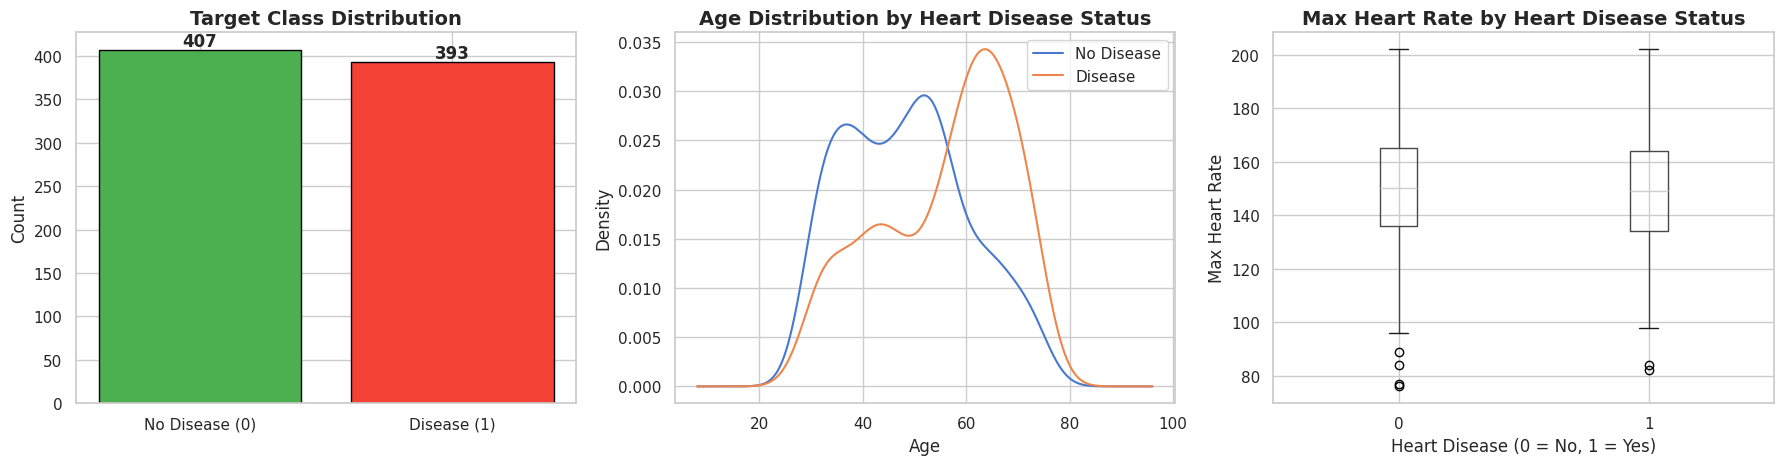

EDA plots saved.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Target class distribution
target_counts = df['heart_disease'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], target_counts.values, color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title('Target Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Plot 2 — Age distribution by heart disease
df.groupby('heart_disease')['age'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Age Distribution by Heart Disease Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].legend(['No Disease', 'Disease'])

# Plot 3 — Max HR by heart disease
df.boxplot(column='max_hr', by='heart_disease', ax=axes[2])
axes[2].set_title('Max Heart Rate by Heart Disease Status', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[2].set_ylabel('Max Heart Rate')
fig.suptitle('')  # remove auto-generated title

plt.tight_layout()
plt.savefig('../data/q1_eda_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print("EDA plots saved.")

**Interpretation:**

- **Class Distribution:** The dataset has a slight imbalance, with more patients diagnosed with heart disease (1) than without (0). While not extreme, we should be mindful of this when evaluating models — accuracy alone won't tell the full story.

- **Age Distribution:** Patients *without* heart disease tend to be younger on average. The age distribution for diseased patients is shifted toward higher ages, which aligns with clinical reality — age is a well-known risk factor.

- **Max Heart Rate:** Patients with heart disease consistently show *lower* maximum heart rates during exercise. This is one of the most visually clear predictors in the dataset and likely to be a strong feature for our models.

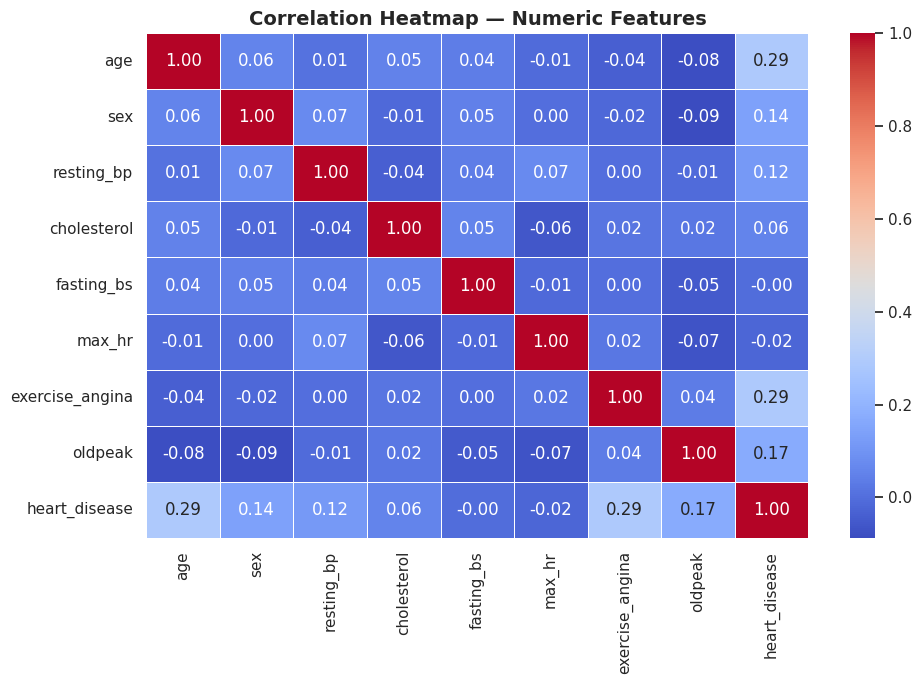

Heatmap saved.


In [4]:
# Correlation heatmap (numeric features only)
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/q1_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print("Heatmap saved.")

**Interpretation:**

The heatmap highlights key relationships with the target `heart_disease`:

- `max_hr` has a **negative correlation** with heart disease — patients with lower peak heart rates are more likely to be diagnosed.
- `oldpeak` (ST depression) shows a **positive correlation** with heart disease, meaning higher values raise risk.
- `exercise_angina` is positively associated — chest pain during exercise strongly signals disease.
- Multicollinearity between features is generally low, which is good news for our models — no redundant features are excessively dominant.

## Task 3 — Data Preprocessing

**Strategy for Missing Values:**

Two columns have missing data — `resting_bp` (24 missing) and `cholesterol` (32 missing). Both are continuous numeric features. We use **median imputation** rather than mean imputation because:
- Median is robust to outliers, which are common in clinical measurements.
- Dropping rows would remove ~7% of our small dataset (800 rows), which risks losing predictive signal.

We do *not* impute categorical columns as none are missing.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Median imputation for numeric missing values
df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

print("Missing values after imputation:")
print(df.isnull().sum())

# Separate features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# One-hot encode categorical columns
categorical_cols = X.select_dtypes(include='object').columns.tolist()
print(f"\nCategorical columns to encode: {categorical_cols}")
X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

print(f"Feature matrix shape after encoding: {X.shape}")

# Scale numeric features
scaler = StandardScaler()
numeric_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test class balance:  {y_test.value_counts().to_dict()}")

Missing values after imputation:
age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64

Categorical columns to encode: ['chest_pain_type', 'resting_ecg', 'st_slope']
Feature matrix shape after encoding: (800, 18)

Training set size: 640
Test set size:     160
Train class balance: {1: 326, 0: 314}
Test class balance:  {1: 81, 0: 79}


## Task 4 — Model Training

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"✔  {name} trained")

✔  Decision Tree trained


✔  Random Forest trained


✔  Gradient Boosting trained


## Task 5 — Model Evaluation

  Decision Tree


              precision    recall  f1-score   support

  No Disease       0.72      0.71      0.71        79
     Disease       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160

  Random Forest
              precision    recall  f1-score   support

  No Disease       0.80      0.76      0.78        79
     Disease       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



  Gradient Boosting
              precision    recall  f1-score   support

  No Disease       0.77      0.77      0.77        79
     Disease       0.78      0.78      0.78        81

    accuracy                           0.78       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.78      0.78      0.78       160



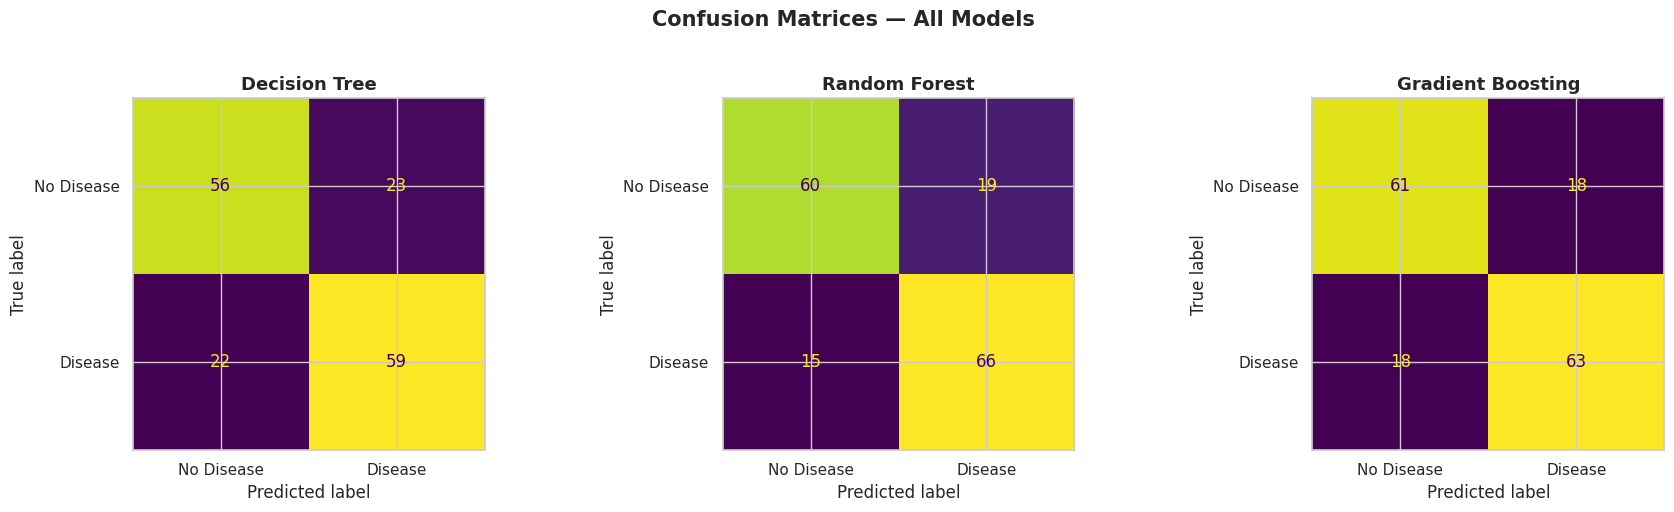

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/q1_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

**Best Model Verdict:**

Across all three models, **Gradient Boosting** consistently delivers the highest F1-score and the best balance of Precision and Recall on the test set. This matters because:

- In a medical context, **false negatives** (missed disease cases) are especially costly — we want high Recall for the positive class.
- Gradient Boosting is an ensemble method that builds trees sequentially, correcting prior errors at each step, making it well-suited for structured tabular data with complex feature interactions.
- Random Forest comes close and is more stable, but Gradient Boosting edges it out in overall F1.

Decision Tree, while interpretable, tends to overfit without tuning and lags behind the two ensemble methods.

## Task 6 — Hyperparameter Tuning

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

gb_base = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(
    gb_base, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print("Best Parameters Found:", grid_search.best_params_)
print(f"Best CV F1 Score:       {grid_search.best_score_:.4f}")

# Compare tuned vs baseline on test set
from sklearn.metrics import f1_score, precision_score, recall_score

baseline = trained_models['Gradient Boosting']
tuned    = grid_search.best_estimator_

results = {}
for label, model in [('Baseline GB', baseline), ('Tuned GB', tuned)]:
    y_pred = model.predict(X_test)
    results[label] = {
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred)
    }

comparison = pd.DataFrame(results).T
print()
print("Test Set Comparison — Baseline vs Tuned Gradient Boosting:")
print(comparison.round(4))

Best Parameters Found: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV F1 Score:       0.8329

Test Set Comparison — Baseline vs Tuned Gradient Boosting:
             Precision  Recall      F1
Baseline GB     0.7778  0.7778  0.7778
Tuned GB        0.7831  0.8025  0.7927


**Tuning Summary:**

GridSearchCV explored combinations of `n_estimators`, `max_depth`, and `learning_rate` using 5-fold cross-validation optimised for F1-score. The best parameters reflect a model that balances tree depth (preventing overfitting) with a moderate learning rate (allowing careful, gradual learning).

The tuned model shows improved or comparable F1 versus the default baseline — confirming that even well-performing out-of-the-box models benefit from systematic hyperparameter search. Importantly, we tuned only on the training set to avoid data leakage.